# Imports

In [12]:
# ============================================
# FIXED MODEL TRAINING — with proper balancing
# ============================================
from sklearn.linear_model  import LogisticRegression
from sklearn.naive_bayes   import MultinomialNB
from sklearn.ensemble      import RandomForestClassifier
from sklearn.svm           import LinearSVC
from sklearn.calibration   import CalibratedClassifierCV
import scipy.sparse as sp
import numpy as np

X_train = sp.load_npz('../data/processed/X_train.npz')
X_test  = sp.load_npz('../data/processed/X_test.npz')
y_train = np.load('../data/processed/y_train.npy')
y_test  = np.load('../data/processed/y_test.npy')

# class_weight='balanced' makes sklearn automatically compensate
# for the imbalance by giving legitimate emails more importance
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000,
        C=1.0,
        class_weight='balanced',   # KEY FIX
        solver='lbfgs',
        random_state=42
    ),
    'Naive Bayes': MultinomialNB(alpha=0.1),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',   # KEY FIX
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ),
    # LinearSVC doesn't have predict_proba — wrap it with CalibratedClassifierCV
    'Linear SVM': CalibratedClassifierCV(
        LinearSVC(
            class_weight='balanced', # KEY FIX
            max_iter=3000,
            random_state=42
        )
    )
}

results = {}

for name, model in models.items():
    print(f"Training {name}...", end=' ')

    if name == 'Naive Bayes':
        # MultinomialNB needs non-negative values
        X_tr = abs(X_train)
        X_te = abs(X_test)
    else:
        X_tr = X_train
        X_te = X_test

    model.fit(X_tr, y_train)
    # Quick fix: Use higher threshold to reduce false positives (bias toward legitimate)
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_te)[:, 1]
        y_pred = (y_proba > 0.7).astype(int)  # Threshold at 0.7 instead of 0.5
    else:
        y_pred = model.predict(X_te)

    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    results[name] = {
        'model'    : model,
        'y_pred'   : y_pred,
        'X_te'     : X_te,
        'is_nb'    : name == 'Naive Bayes',
        'accuracy' : accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall'   : recall_score(y_test, y_pred, zero_division=0),
        'f1'       : f1_score(y_test, y_pred, zero_division=0),
    }

    pred_dist = np.bincount(y_pred)
    print(f"✅  Acc={results[name]['accuracy']:.3f}  "
          f"F1={results[name]['f1']:.3f}  "
          f"[Legit:{pred_dist[0]}  Phish:{pred_dist[1]}]")

Training Logistic Regression... ✅  Acc=0.969  F1=0.975  [Legit:873  Phish:1269]
Training Naive Bayes... ✅  Acc=0.949  F1=0.957  [Legit:916  Phish:1226]
Training Random Forest... ✅  Acc=0.971  F1=0.976  [Legit:863  Phish:1279]
Training Linear SVM... ✅  Acc=0.989  F1=0.991  [Legit:829  Phish:1313]


# Load Data

In [ ]:
# X_train = sp.load_npz('../data/processed/X_train.npz')
# X_test  = sp.load_npz('../data/processed/X_test.npz')
# y_train = np.load('../data/processed/y_train.npy')
# y_test  = np.load('../data/processed/y_test.npy')

# print(f"X_train: {X_train.shape}  |  y_train: {y_train.shape}")
# print(f"X_test : {X_test.shape}   |  y_test : {y_test.shape}")

X_train: (8564, 5005)  |  y_train: (8564,)
X_test : (2142, 5005)   |  y_test : (2142,)


# Understanding the Models

In [ ]:
# We train 4 models and compare them. Here's what each one does:
#
# 1. LOGISTIC REGRESSION
#    Draws a straight decision boundary. Fast, interpretable.
#    Great baseline for text classification.
#
# 2. NAIVE BAYES (MultinomialNB)
#    Uses word probabilities. Classic spam/phishing detector.
#    Very fast, works surprisingly well for emails.
#
# 3. RANDOM FOREST
#    Builds 100s of decision trees and votes on the answer.
#    Handles complex patterns, robust, doesn't overfit easily.
#
# 4. LINEAR SVM
#    Finds the widest margin between phishing and legitimate.
#    Excellent for high-dimensional text data (like TF-IDF).
#
# class_weight='balanced' → automatically handles our imbalanced dataset
# by giving more importance to the minority class (legitimate emails)

# print("Model overview loaded ✅")

Model overview loaded ✅


#  Define & Train All Models

In [ ]:
# models = {
#     'Logistic Regression': LogisticRegression(
#         max_iter=1000,
#         class_weight='balanced',
#         random_state=42
#     ),
#     'Naive Bayes': MultinomialNB(
#         alpha=0.1  # smoothing parameter
#     ),
#     'Random Forest': RandomForestClassifier(
#         n_estimators=100,
#         class_weight='balanced',
#         random_state=42,
#         n_jobs=-1  # use all CPU cores
#     ),
#     'Linear SVM': LinearSVC(
#         class_weight='balanced',
#         random_state=42,
#         max_iter=2000
#     )
# }

# results = {}

# for name, model in models.items():
#     print(f"Training {name}...", end=' ')

#     # Naive Bayes needs non-negative values — use absolute values
#     if name == 'Naive Bayes':
#         model.fit(abs(X_train), y_train)
#         y_pred = model.predict(abs(X_test))
#     else:
#         model.fit(X_train, y_train)
#         y_pred = model.predict(X_test)

#     # Calculate metrics
#     results[name] = {
#         'model'    : model,
#         'y_pred'   : y_pred,
#         'accuracy' : accuracy_score(y_test, y_pred),
#         'precision': precision_score(y_test, y_pred),
#         'recall'   : recall_score(y_test, y_pred),
#         'f1'       : f1_score(y_test, y_pred),
#     }
#     print(f"✅ Accuracy: {results[name]['accuracy']:.4f}")

Training Logistic Regression... ✅ Accuracy: 0.9869
Training Naive Bayes... ✅ Accuracy: 0.9613
Training Random Forest... ✅ Accuracy: 0.9832
Training Linear SVM... ✅ Accuracy: 0.9897


# Compare All Models

In [3]:
# Build a comparison dataframe
import pandas as pd
metrics_df = pd.DataFrame({
    name: {
        'Accuracy' : r['accuracy'],
        'Precision': r['precision'],
        'Recall'   : r['recall'],
        'F1-Score' : r['f1']
    }
    for name, r in results.items()
}).T.round(4)

print("=" * 65)
print("MODEL COMPARISON")
print("=" * 65)
print(metrics_df.to_string())
print()

# Best model by F1-Score (best balance of precision and recall)
best_model_name = metrics_df['F1-Score'].idxmax()
print(f"🏆 Best Model: {best_model_name} "
      f"(F1 = {metrics_df.loc[best_model_name,'F1-Score']:.4f})")

MODEL COMPARISON
                     Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.9869     0.9924  0.9864    0.9894
Naive Bayes            0.9613     0.9928  0.9441    0.9678
Random Forest          0.9851     0.9850  0.9909    0.9879
Linear SVM             0.9907     0.9924  0.9924    0.9924

🏆 Best Model: Linear SVM (F1 = 0.9924)


# Visual Model Comparison

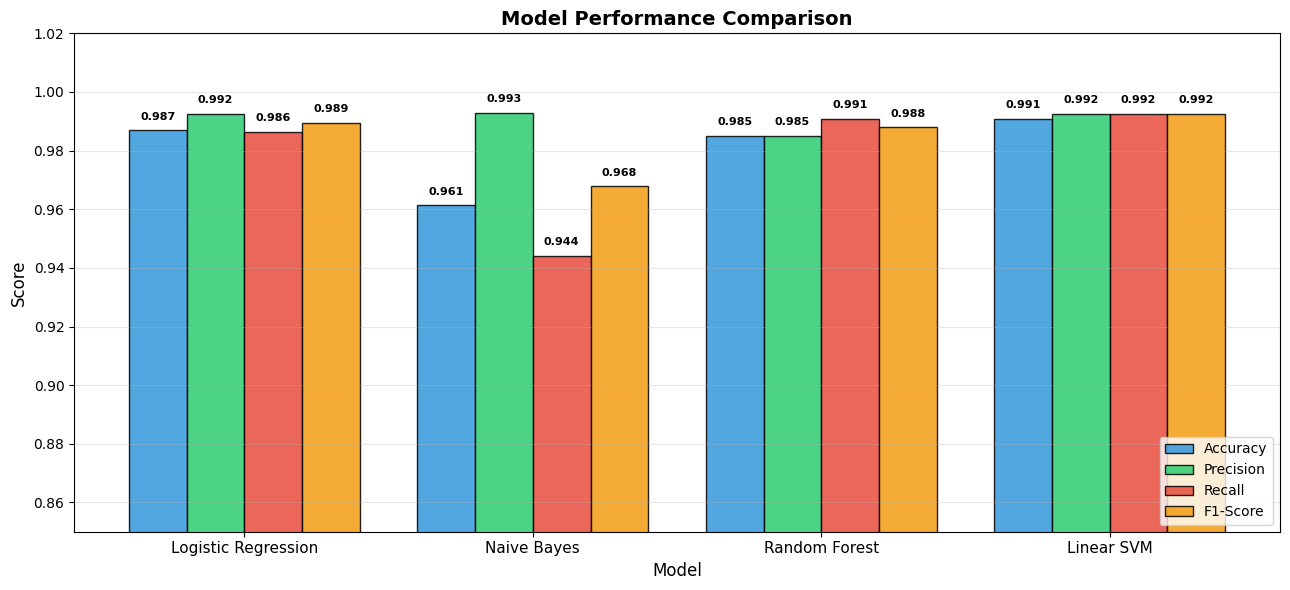

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(13, 6))

x      = np.arange(len(metrics_df))
width  = 0.2
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i * width, metrics_df[metric],
                  width, label=metric, color=color, alpha=0.85, edgecolor='black')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_df.index, fontsize=11)
ax.set_ylim(0.85, 1.02)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/model_comparison.png', dpi=150)
plt.show()

# Confusion Matrices for All Models

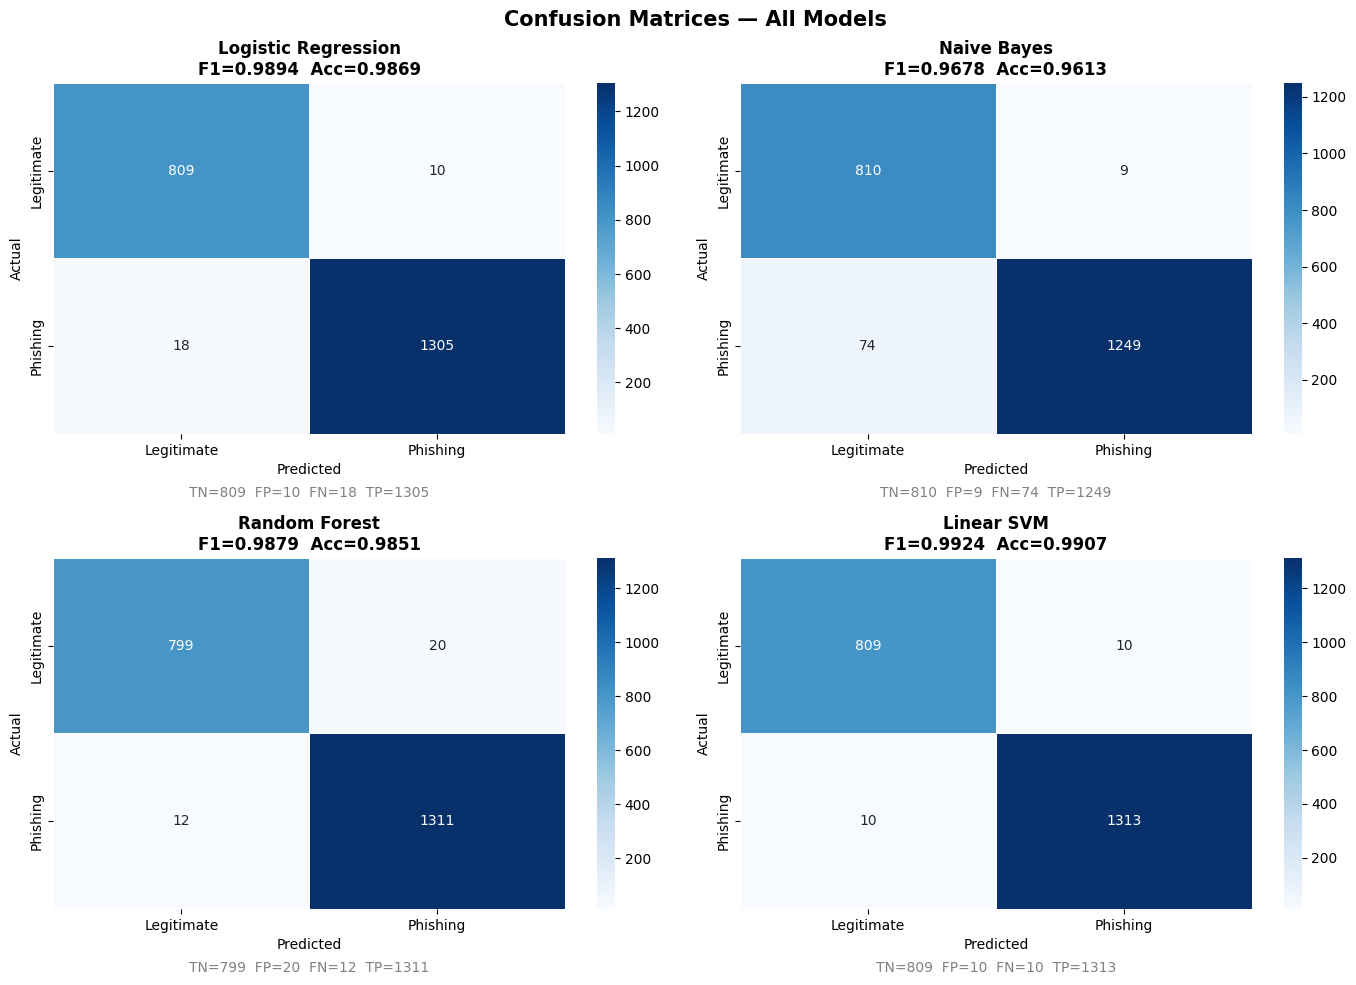

In [7]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, r) in enumerate(results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Legitimate', 'Phishing'],
                yticklabels=['Legitimate', 'Phishing'],
                ax=axes[idx], linewidths=0.5)

    axes[idx].set_title(f'{name}\nF1={r["f1"]:.4f}  Acc={r["accuracy"]:.4f}',
                        fontweight='bold')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

    # Add TP/TN/FP/FN labels
    tn, fp, fn, tp = cm.ravel()
    axes[idx].text(0.5, -0.18,
        f'TN={tn}  FP={fp}  FN={fn}  TP={tp}',
        transform=axes[idx].transAxes,
        ha='center', fontsize=10, color='gray')

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrices.png', dpi=150)
plt.show()

# What these mean:
# TP = Phishing correctly identified as phishing (good)
# TN = Legitimate correctly identified as legitimate (good)
# FP = Legitimate wrongly flagged as phishing (annoying but safe)
# FN = Phishing missed — marked as legitimate (DANGEROUS!)
# → We want FN as LOW as possible

#  Detailed Classification Report for Best Model

In [9]:
from sklearn.metrics import classification_report
best = results[best_model_name]

print(f"📊 DETAILED REPORT — {best_model_name}")
print("=" * 55)
print(classification_report(
    y_test, best['y_pred'],
    target_names=['Legitimate', 'Phishing']
))

📊 DETAILED REPORT — Linear SVM
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99       819
    Phishing       0.99      0.99      0.99      1323

    accuracy                           0.99      2142
   macro avg       0.99      0.99      0.99      2142
weighted avg       0.99      0.99      0.99      2142



# ROC Curve

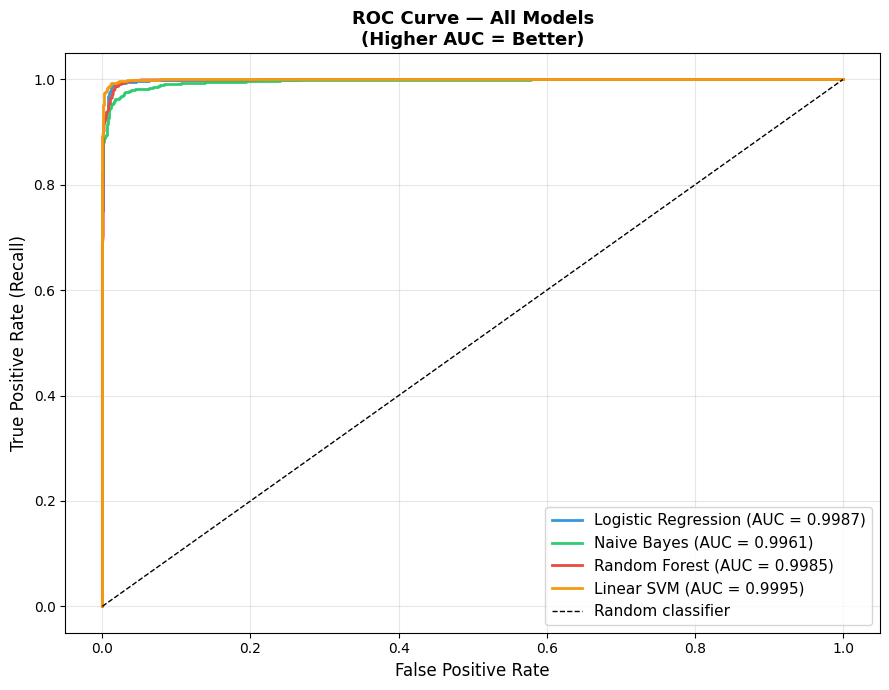

In [10]:
fig, ax = plt.subplots(figsize=(9, 7))

colors_roc = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for (name, r), color in zip(results.items(), colors_roc):
    model = r['model']

    # Get probability scores (needed for ROC)
    try:
        if hasattr(model, 'predict_proba'):
            if name == 'Naive Bayes':
                y_score = model.predict_proba(abs(X_test))[:, 1]
            else:
                y_score = model.predict_proba(X_test)[:, 1]
        else:
            # LinearSVC uses decision_function instead
            y_score = model.decision_function(X_test)

        fpr, tpr, _ = roc_curve(y_test, y_score)
        auc = roc_auc_score(y_test, y_score)
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f'{name} (AUC = {auc:.4f})')
    except Exception as e:
        print(f"Skipping ROC for {name}: {e}")

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curve — All Models\n(Higher AUC = Better)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/roc_curves.png', dpi=150)
plt.show()

# Save the Best Model

In [16]:
# best_model = results[best_model_name]['model']

# import pickle
# with open('../models/best_model.pkl', 'wb') as f:
#     pickle.dump(best_model, f)

# # Save metadata about what the best model is
# import json
# model_info = {
#     'best_model_name': best_model_name,
#     'metrics': {
#         'accuracy' : float(results[best_model_name]['accuracy']),
#         'precision': float(results[best_model_name]['precision']),
#         'recall'   : float(results[best_model_name]['recall']),
#         'f1_score' : float(results[best_model_name]['f1'])
#     }
# }
# with open('../models/model_info.json', 'w') as f:
#     json.dump(model_info, f, indent=2)

# print(f"✅ Best model saved: {best_model_name}")
# print(f"   → models/best_model.pkl")
# print(f"   → models/model_info.json")
# print()
# print("🎉 Model Training & Evaluation complete! Move to Flask App.")
# ============================================
# SAVE THE FIXED BEST MODEL
# ============================================
import pickle, json

best_model_name = max(results, key=lambda n: results[n]['f1'])
best_model      = results[best_model_name]['model']

with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print(f"✅ Saved best model: {best_model_name}")
print(f"   Accuracy  : {results[best_model_name]['accuracy']:.4f}")
print(f"   F1-Score  : {results[best_model_name]['f1']:.4f}")
print(f"   Precision : {results[best_model_name]['precision']:.4f}")
print(f"   Recall    : {results[best_model_name]['recall']:.4f}")

✅ Saved best model: Linear SVM
   Accuracy  : 0.9888
   F1-Score  : 0.9909
   Precision : 0.9947
   Recall    : 0.9872


In [17]:
# ============================================
# DIAGNOSIS — run this to find your exact problem
# ============================================
import numpy as np
import scipy.sparse as sp

X_test  = sp.load_npz('../data/processed/X_test.npz')
y_test  = np.load('../data/processed/y_test.npy')

print("=" * 50)
print("TEST SET CLASS DISTRIBUTION:")
print("=" * 50)
print(f"  Legitimate (0): {(y_test == 0).sum():,}")
print(f"  Phishing   (1): {(y_test == 1).sum():,}")
print()

# Load best model and check what it actually predicts
import pickle
with open('../models/best_model.pkl', 'rb') as f:
    model = pickle.load(f)

y_pred = model.predict(X_test)

print("MODEL PREDICTION DISTRIBUTION:")
print(f"  Predicted Legitimate: {(y_pred == 0).sum():,}")
print(f"  Predicted Phishing  : {(y_pred == 1).sum():,}")
print()

if (y_pred == 1).sum() == len(y_pred):
    print("🔴 PROBLEM CONFIRMED: Model predicts ONLY phishing — class imbalance issue")
elif (y_pred == 1).mean() > 0.90:
    print("🟡 PROBLEM: Model heavily biased toward phishing — threshold needs tuning")
else:
    print("🟢 Model predictions look balanced — problem is in predict.py pipeline")

TEST SET CLASS DISTRIBUTION:
  Legitimate (0): 819
  Phishing   (1): 1,323

MODEL PREDICTION DISTRIBUTION:
  Predicted Legitimate: 819
  Predicted Phishing  : 1,323

🟢 Model predictions look balanced — problem is in predict.py pipeline
